In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load built-in dataset

In [3]:
# Load a built-in dataset for examples
tips = sns.load_dataset("tips")
penguins = sns.load_dataset("penguins")
flights = sns.load_dataset("flights")
iris = sns.load_dataset("iris")

In [5]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [6]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Differene between figure level function and axis level function


### Figure level function

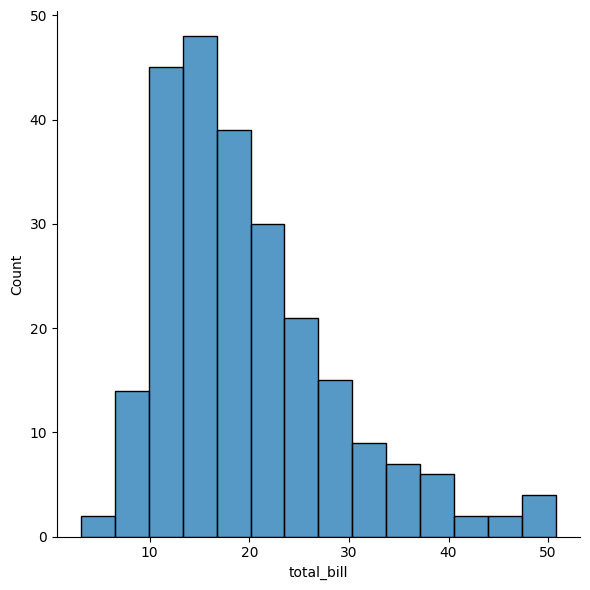

In [16]:
sns.displot(data=tips, x="total_bill", height=6, aspect=1)
plt.show()

### Axes level function

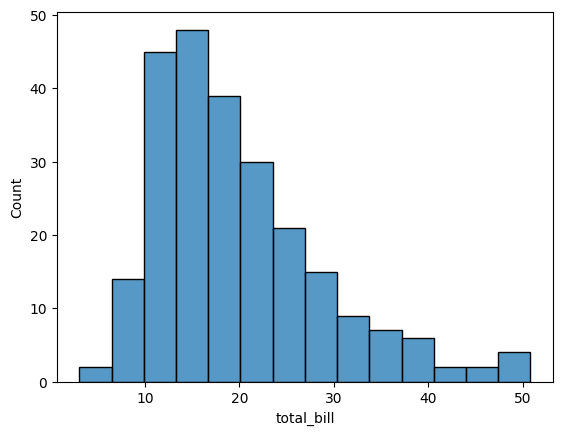

In [14]:
sns.histplot(x=tips["total_bill"])
plt.show()

### Faceting

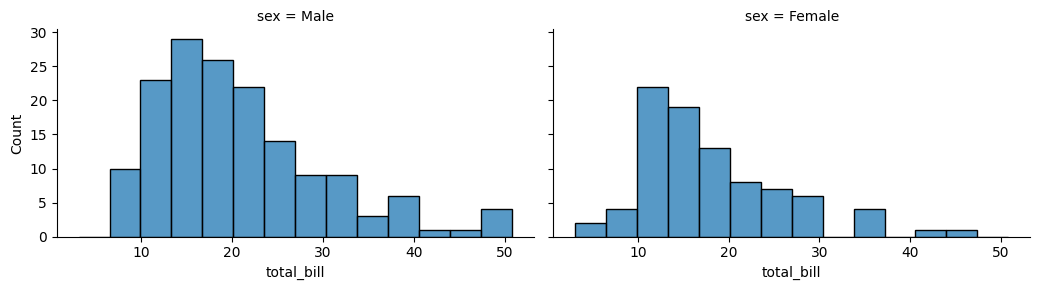

In [ ]:
# Faceting in figure level function

sns.displot(kind="hist", data=tips, x="total_bill", col="sex", height=3, aspect=1.75)
plt.show()

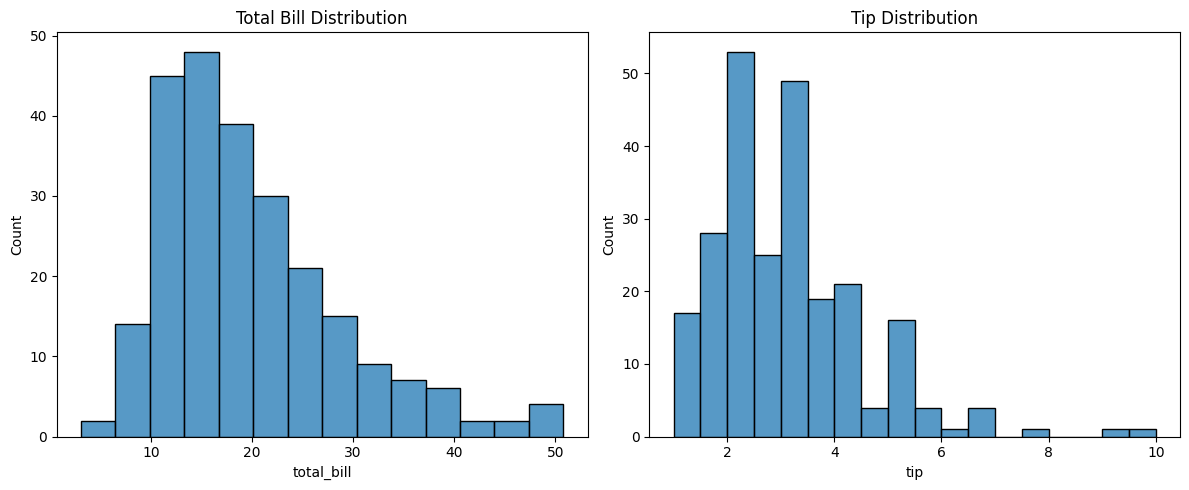

In [19]:
# Faceting in axes level function

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=tips, x="total_bill", ax=axes[0])
axes[0].set_title("Total Bill Distribution")

sns.histplot(data=tips, x="tip", ax=axes[1])
axes[1].set_title("Tip Distribution")

plt.tight_layout()
plt.show()

## Figure level functions


### displot()


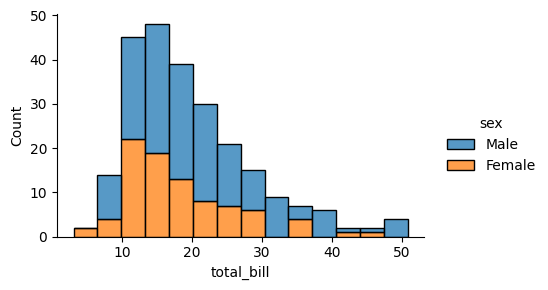

In [22]:
# Default: histogram
sns.displot(data=tips, x="total_bill", hue="sex", multiple="stack", height=3, aspect=1.5)
plt.show()

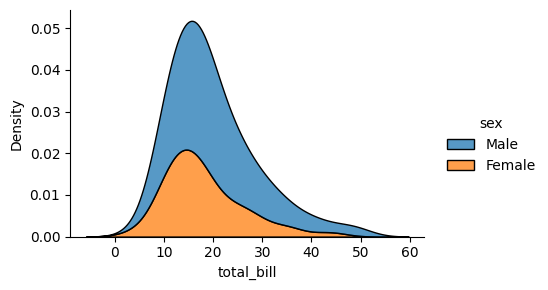

In [25]:
# KDE plot
sns.displot(data=tips, x="total_bill", kind="kde", hue="sex", fill=True, multiple="stack", height=3, aspect=1.5)
plt.show()

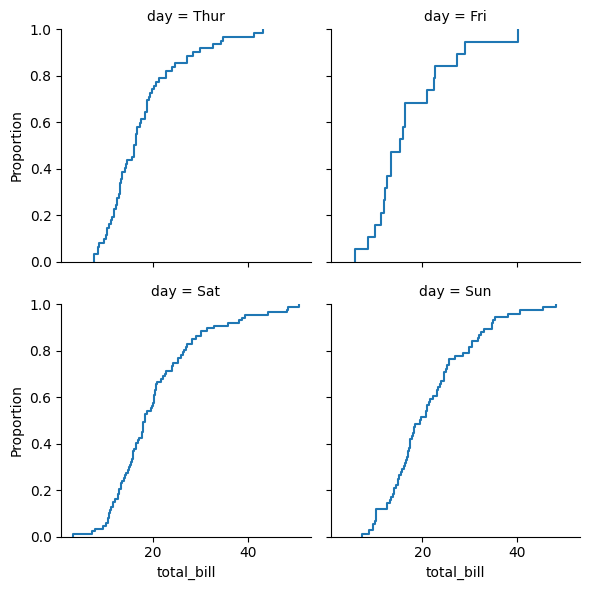

In [37]:
# ECDF plot with faceting
sns.displot(data=tips, x="total_bill", kind="ecdf", col="day", height=3, col_wrap=2)
plt.show()

### relplot()

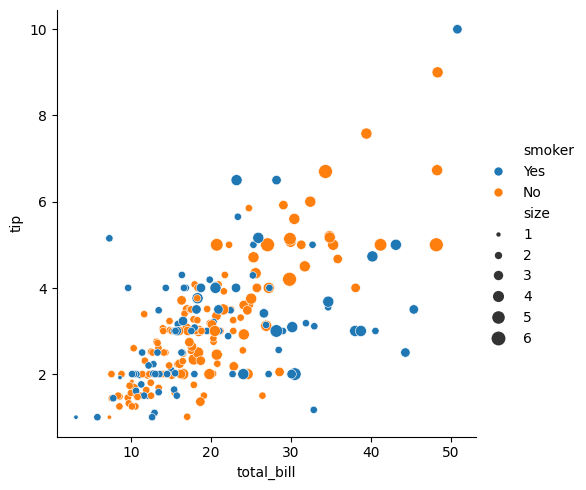

In [36]:
# Default: scatter plot
sns.relplot(data=tips, x="total_bill", y="tip", hue="smoker", size="size", sizes=(10, 100))
plt.show()

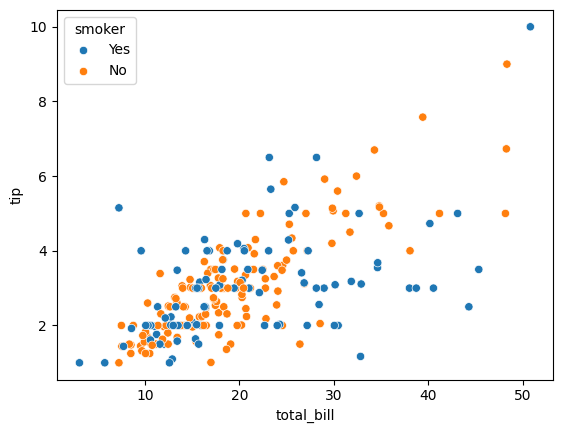

In [28]:
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="smoker")
plt.show()

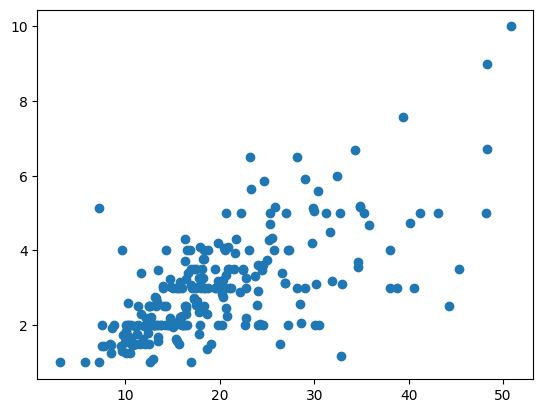

In [29]:
plt.scatter(x=tips["total_bill"], y=tips["tip"])

## Line plot()

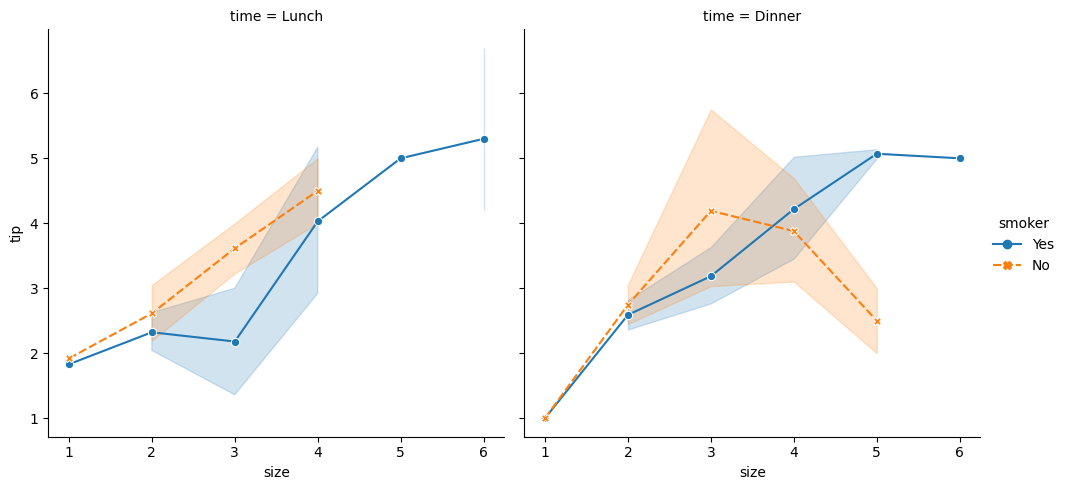

In [34]:
# Switch to line plot with kind parameter
sns.relplot(
    data=tips,
    x="size",
    y="tip",
    kind="line",
    hue="smoker",
    style="smoker",
    markers=True,
    col="time"  # facet by time (Lunch/Dinner)
)
plt.show()

## Catplot()

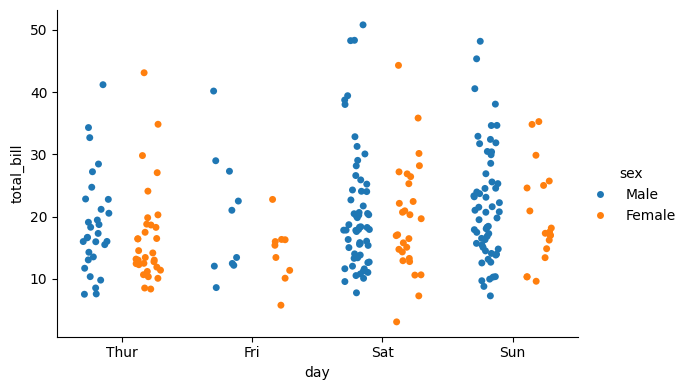

In [41]:
# Default: strip plot
sns.catplot(data=tips, x="day", y="total_bill", height=4, aspect=1.5, hue="sex", dodge=True, jitter=0.2)
plt.show()

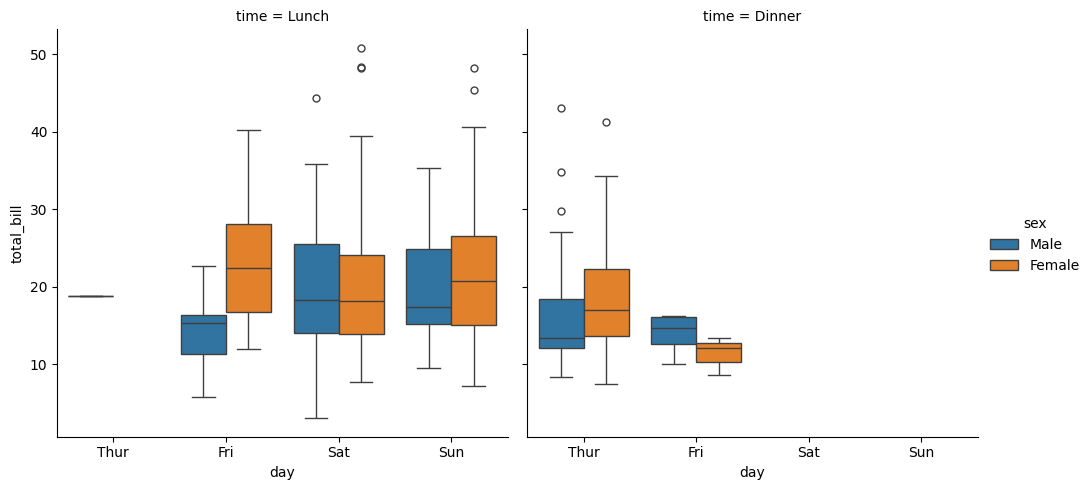

In [49]:
# Violin with faceting
sns.catplot(
    data=tips,
    x="day",
    y="total_bill",
    kind="box",
    hue="sex",
    # split=True,      # split violins by hue
    # palette="pastel",
    col="time",
    height=5
)
plt.show()

## Axes-level function

### Relational axes plot

#### Scatterplot()

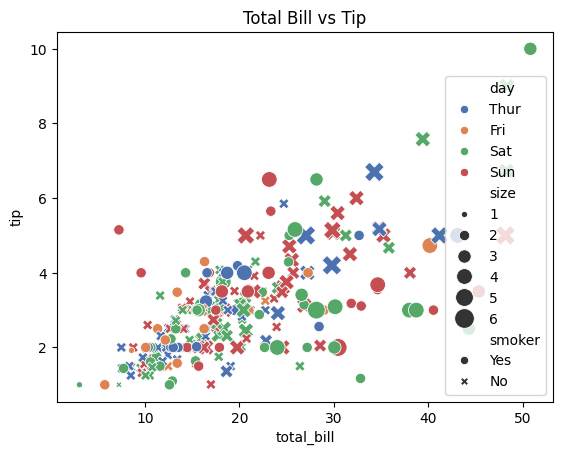

In [56]:
# With hue, size, and style
sns.scatterplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="day",          # color by day
    size="size",       # point size by party size
    style="smoker",     # marker style by smoking status
    palette="deep",
    sizes=(20, 200)    # min and max point sizes
)
plt.title("Total Bill vs Tip")
plt.show()

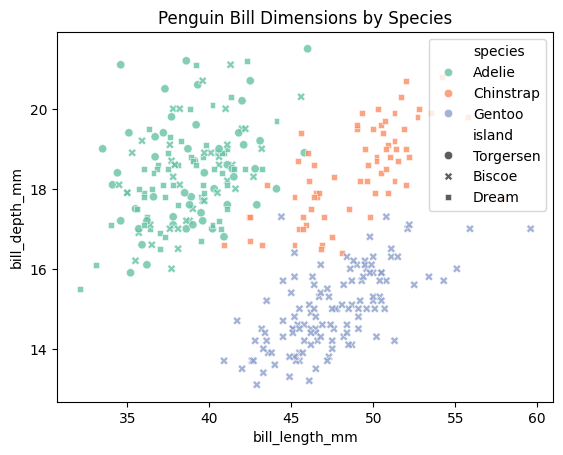

In [57]:
# Real-world: penguin bill dimensions by species
sns.scatterplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    style="island",
    alpha=0.8,
    palette="Set2"
)
plt.title("Penguin Bill Dimensions by Species")
plt.show()

### Line plot()

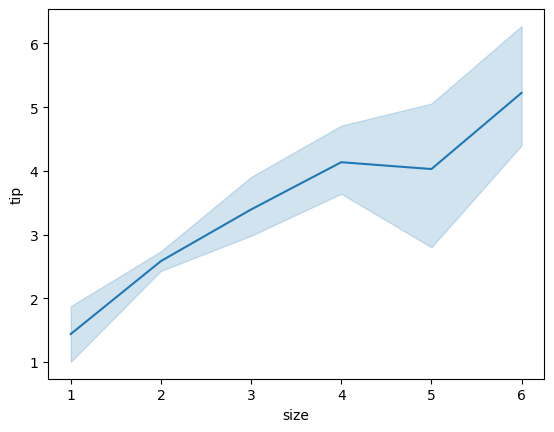

In [58]:
# Basic line plot
sns.lineplot(data=tips, x="size", y="tip")
plt.show()

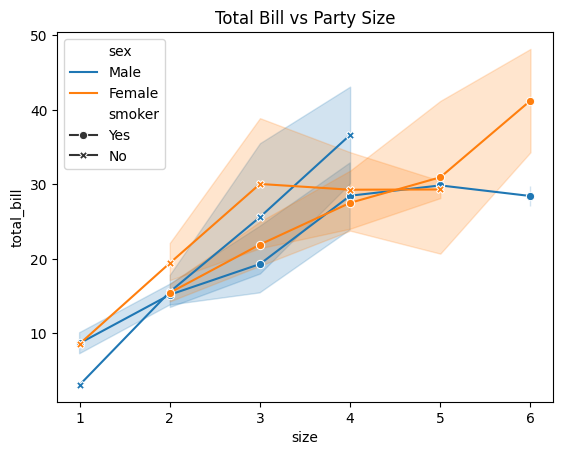

In [59]:
# With confidence interval by group
sns.lineplot(
    data=tips,
    x="size",
    y="total_bill",
    hue="sex",
    style="smoker",
    markers=True,
    dashes=False,
    errorbar="ci"       # show 95% confidence interval
)
plt.title("Total Bill vs Party Size")
plt.show()

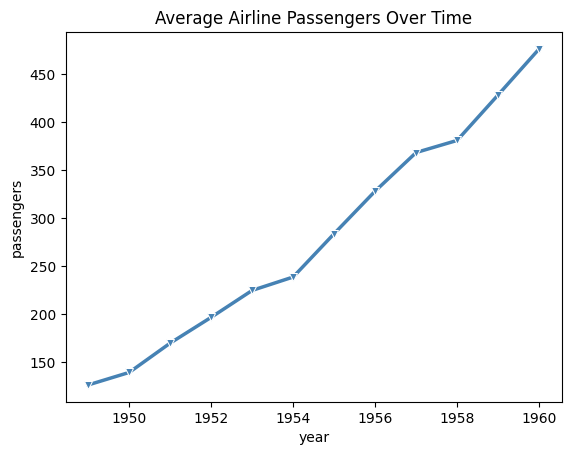

In [63]:
# Time-series style with flights dataset
flights_avg = flights.groupby("year")["passengers"].mean().reset_index()

sns.lineplot(
    data=flights_avg,
    x="year",
    y="passengers",
    marker="v",
    color="steelblue",
    linewidth=2.5
)
plt.title("Average Airline Passengers Over Time")
plt.show()

## Distribution plots Axes-level

#### One dimensional histograms

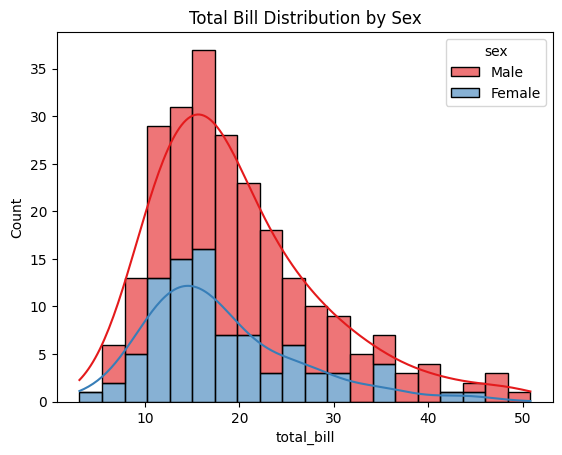

In [66]:
# Overlapping histograms with KDE
sns.histplot(
    data=tips,
    x="total_bill",
    hue="sex",
    multiple="stack",   # options: "layer", "dodge", "stack", "fill"
    kde=True,           # overlay KDE curve
    bins=20,
    palette="Set1",
    alpha=0.6
)
plt.title("Total Bill Distribution by Sex")
plt.show()

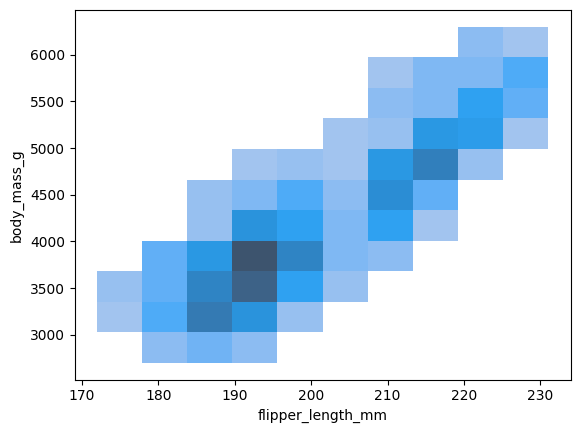

In [67]:
# 2D histogram (bivariate)
sns.histplot(data=penguins, x="flipper_length_mm", y="body_mass_g")
plt.show()

### Kdeplot()

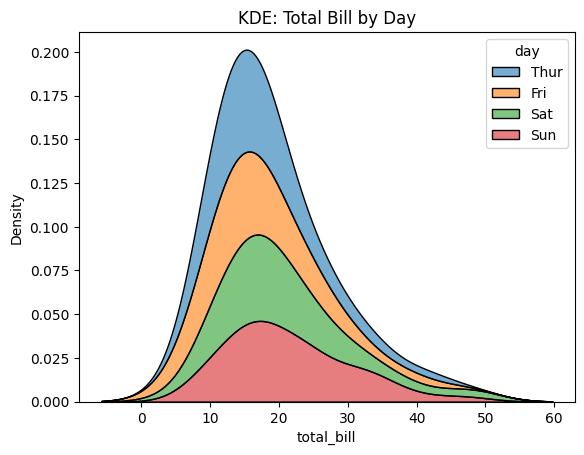

In [69]:
# Filled KDE for multiple groups
sns.kdeplot(
    data=tips,
    x="total_bill",
    hue="day",
    fill=True,
    alpha=0.6,
    palette="tab10",
    multiple="stack",
    common_norm=False    # each group normalized independently
)
plt.title("KDE: Total Bill by Day")
plt.show()

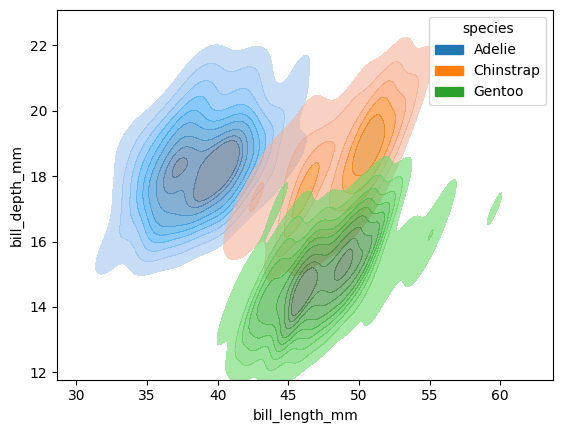

In [72]:
# 2D density contour plot
sns.kdeplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    fill=True,
    multiple="stack",
    alpha=0.6,
    thresh=0.05          # threshold for lowest contour
)
plt.show()

### ecdfplot()

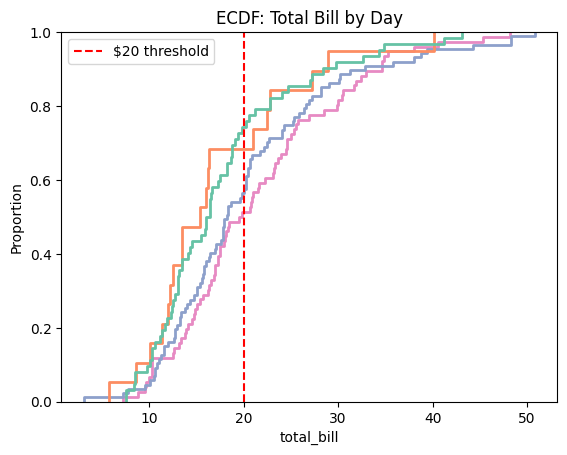

In [73]:
# Compare groups with ECDF
sns.ecdfplot(
    data=tips,
    x="total_bill",
    hue="day",
    palette="Set2",
    linewidth=2
)
plt.title("ECDF: Total Bill by Day")
plt.axvline(20, color="red", linestyle="--", label="$20 threshold")
plt.legend()
plt.show()

### Rugplot()

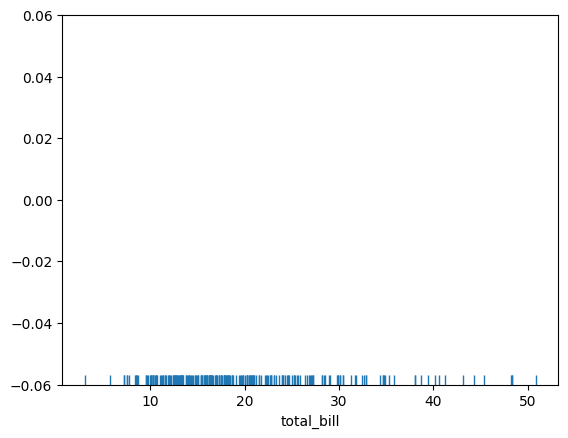

In [74]:
# Standalone rug plot
sns.rugplot(data=tips, x="total_bill")
plt.show()

#### Rug plot combined with KDE

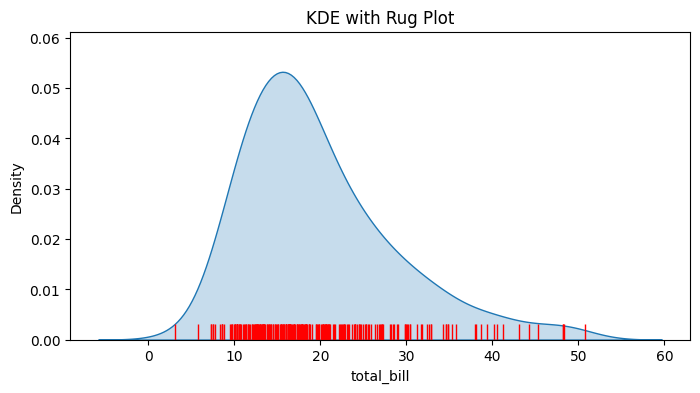

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(data=tips, x="total_bill", fill=True, ax=ax)
sns.rugplot(data=tips, x="total_bill", ax=ax, height=0.05, color="red")
plt.title("KDE with Rug Plot")
plt.show()